<a href="https://colab.research.google.com/github/s34836/HTW_Biometrics/blob/main/presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Needed PyTorch Packages
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

# Define Parameters
N_INPUTS = 1
N_NEURONS = 5
N_OUTPUTS = 1
N_EPOCHS = 20
BATCH_SIZE = 4
LEARNING_RATE = 0.001
MOMENTUM = 0.9

# Create Cosine Wave Data With Added Random Noise
x = np.arange(1, 720 + 1, 1)
y = np.cos(x * np.pi / 180) + np.random.randn(720) * 0.05

# Structure Data For Use With RNN:
# Input Sequence: [point 1, point 2, ..., point 10]
# Prediction: [point 11].
X = []
Y = []

for i in range(0, 710):
    list1 = []
    for j in range(i, i + 10):
        list1.append(y[j])
    X.append(list1)
    Y.append(y[j + 1])

# Split Data into Train and Test Sets
X = np.array(X)
Y = np.array(Y)

X_train = X[:360]
X_test = X[360:]
y_train = Y[:360]
y_test = Y[360:]


class ExampleRNN(nn.Module):
    # Setup the ExampleRNN class
    def __init__(self, batch_size=4, n_inputs=1, n_neurons=5, n_outputs=1):
        super(ExampleRNN, self).__init__()

        self.batch_size = batch_size
        self.n_neurons = n_neurons

        # Hidden Layer with Recurrent Edge
        self.basic_rnn = nn.RNN(n_inputs, n_neurons, batch_first=True)

        # Fully-Connected Layer
        self.FC = nn.Linear(n_neurons, n_outputs)

    # Reset The Hidden Layer Before Inputting a New Sequence
    def init_hidden(self):
        return torch.zeros(1, self.batch_size, self.n_neurons)

    # Pass A Sequence Forward Through The Network
    def forward(self, X):
        self.batch_size = X.size(0)
        self.hidden = self.init_hidden()

        _, self.hidden = self.basic_rnn(X, self.hidden)
        output = self.FC(self.hidden)

        return output


class TimeSequence(Dataset):
    # Store Sequences and Expected Predictions And Convert To Tensor Format
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.len = X.shape[0]

    # Retrieve a Single Sequence When Needed By DataLoader
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    # Return Number Of Sequences When Needed By DataLoader
    def __len__(self):
        return self.len


# Prepare Train Data
trainset = TimeSequence(X_train, y_train)
trainloader = DataLoader(trainset, shuffle=True, batch_size=BATCH_SIZE)

net = ExampleRNN(BATCH_SIZE, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = torch.nn.MSELoss()
optimizer = optim.SGD(net.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

# Train Network
loss_vals = np.zeros(N_EPOCHS)

for epoch in range(N_EPOCHS):
    running_loss = 0.0

    for i, data in enumerate(trainloader):
        # Reset Gradients to Zero
        optimizer.zero_grad()

        # Separate Input and Ground-Truth Values
        inputs, ground_truth = data

        # Rearrange Input Tensor So It Is In 4x10x1 Shape
        inputs = inputs.view(-1, 10, 1)

        # Forward Propagate
        y_pred = net(inputs)

        # Evaluate Loss For The Batch
        loss = criterion(y_pred.squeeze(), ground_truth)

        # Backpropagate Loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    loss_vals[epoch] = running_loss

    print('[Epoch {}/{}] Loss: {}'.format(epoch + 1, N_EPOCHS, running_loss))


# Prepare Test Data
testset = TimeSequence(X_test, y_test)

# Load All Test Data In A Single Batch
testloader = DataLoader(testset, shuffle=False, batch_size=len(testset))

# During Testing, Gradients Are Not Calculated
with torch.no_grad():
    for data in testloader:
        # Separate Input and Ground-Truth Output
        inputs, ground_truth = data

        # Rearrange Input Tensor So It Is In Nx10x1 Shape
        inputs = inputs.view(-1, 10, 1)

        # Forward Propagate Input
        output = net(inputs)

        # Record Network Predictions And Ground-Truth Values
        test_pred = output.squeeze()
        test_true = ground_truth

[Epoch 1/20] Loss: 24.56926745455712
[Epoch 2/20] Loss: 1.4053868730552495
[Epoch 3/20] Loss: 0.9473326668376103
[Epoch 4/20] Loss: 0.8520962444599718
[Epoch 5/20] Loss: 0.7841842793859541
[Epoch 6/20] Loss: 0.7334935349645093
[Epoch 7/20] Loss: 0.6867354271817021
[Epoch 8/20] Loss: 0.6609822632744908
[Epoch 9/20] Loss: 0.6344186277710833
[Epoch 10/20] Loss: 0.6091491571278311
[Epoch 11/20] Loss: 0.5993690293398686
[Epoch 12/20] Loss: 0.5770367317018099
[Epoch 13/20] Loss: 0.5611127229058184
[Epoch 14/20] Loss: 0.5509010480018333
[Epoch 15/20] Loss: 0.5398837369866669
[Epoch 16/20] Loss: 0.5277041151421145
[Epoch 17/20] Loss: 0.5264820045558736
[Epoch 18/20] Loss: 0.5142199057154357
[Epoch 19/20] Loss: 0.5105090436991304
[Epoch 20/20] Loss: 0.5021414990769699


In [3]:
# Prepare Test Data
testset = TimeSequence(X_test, y_test)

# Load All Test Data In A Single Batch
testloader = DataLoader(
    testset,
    shuffle=False,
    batch_size=len(testset)
)

# During Testing, Gradients Are Not Calculated
with torch.no_grad():
    for data in testloader:
        # Separate Input and Ground-Truth Output
        inputs, ground_truth = data

        # Rearrange Input Tensor So It Is In Nx10x1 Shape
        inputs = inputs.view(-1, 10, 1)

        # Forward Propagate Input
        output = net(inputs)

        # Record Network Predictions And Ground-Truth Values
        test_pred = output.squeeze()
        test_true = ground_truth

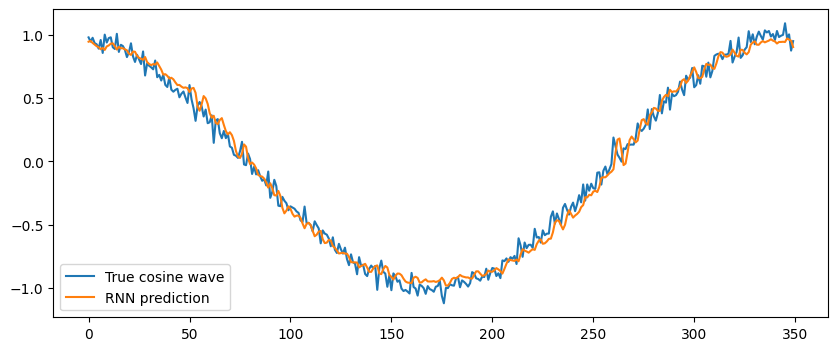

In [4]:
import matplotlib.pyplot as plt

test_pred_np = test_pred.numpy()
test_true_np = test_true.numpy()

plt.figure(figsize=(10, 4))
plt.plot(test_true_np, label="True cosine wave")
plt.plot(test_pred_np, label="RNN prediction")
plt.legend()
plt.show()